# 01. F1 Data Exploration & Ingestion

This notebook demonstrates how we load Grand Prix timing data via FastF1, clean it, apply fuel-corrections, and fit piecewise tire degradation curves with a cliff.

In [1]:
import os
import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

sns.set_theme(style="whitegrid")

# Color palette mapping for compounds as requested
tyre_palette = {
    "SOFT": "red",
    "MEDIUM": "yellow",
    "HARD": "black",
    "INTERMEDIATE": "green",
    "WET": "blue"
}

## 1. Load Silverstone 2022 Race

In [2]:
fastf1.Cache.enable_cache('../data/raw')
session = fastf1.get_session(2022, 'Silverstone', 'R')
session.load(laps=True, telemetry=False, weather=True)

laps = session.laps.copy()
laps["LapTime_s"] = laps["LapTime"].dt.total_seconds()
laps = laps.dropna(subset=["Compound", "TyreLife", "LapTime_s"])
laps["Compound"] = laps["Compound"].str.upper()
print(f"Loaded {len(laps)} laps from {session.event['EventName']} {session.event['EventDate'].year}")

core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['55', '11', '44', '16', '14', '4', '1', '47', '5', '20', '18', '6', '3', '22', '31', '10', '77', '63', '24', '23']


Loaded 773 laps from British Grand Prix 2022


## 2. Plot Raw Lap Times vs Tire Age

### Description & Representation
This plot is a scatterplot of raw lap times (in seconds) on the y-axis plotted against the tire age (`TyreLife` — the number of laps run on the current tire set) on the x-axis, color-coded by compound using the standard F1 color scheme (SOFT=red, MEDIUM=yellow, HARD=black, etc.).

### Technical Details
It displays the unmodified `LapTime` data fetched directly from the FastF1 session laps dataframe (filtered only by FastF1's built-in `pick_quicklaps` to remove outliers). It retains all structural noise, including the base performance gaps between different cars/drivers (e.g. front-runners vs backmarkers) and differences in fuel loads at various points in the race.

### Strategic Insights
The plot shows a highly scattered, vertical spread of points. There is no clear, clean tire wear curve visible because a driver's raw lap time is heavily masked by two major variables:
1. **Driver/Car Pace Variance**: Up to a 3-4 second gap exists between a leading car and a backmarker on the same tires.
2. **Fuel Load Variance**: Cars start the race with up to 110 kg of fuel, losing approximately 1.9 kg/lap. This fuel burn makes the car lighter and naturally faster by $\approx 3$ seconds from start to finish.

This highlights why fitting tire degradation directly on raw data is highly inaccurate and why we must apply fuel corrections and driver-stint pace normalization.

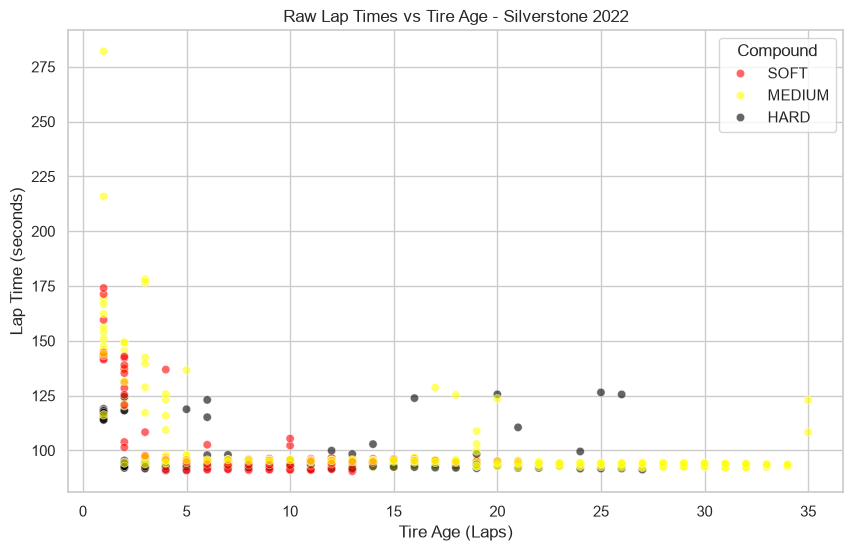

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=laps, x="TyreLife", y="LapTime_s", hue="Compound", palette=tyre_palette, alpha=0.6)
plt.title("Raw Lap Times vs Tire Age - Silverstone 2022")
plt.xlabel("Tire Age (Laps)")
plt.ylabel("Lap Time (seconds)")
plt.show()

## 3. Apply Fuel Correction

### Description & Representation
This plot shows the fuel-corrected lap times (in seconds) on the y-axis against tire age on the x-axis, color-coded by compound.

### Technical Details
We calculate the fuel weight effect on each lap and subtract it to isolate the tire performance. The fuel consumption is modeled linearly at 1.9 kg/lap, and the fuel weight sensitivity is modeled at 0.033 s/kg. The formula is:
$$T_{\text{corrected}} = T_{\text{raw}} - (\text{Laps Remaining} \times 1.9\text{ kg/lap} \times 0.033\text{ s/kg})$$

### Strategic Insights
The scatter plot distribution tightens vertically compared to the raw plot because it successfully isolates the tire performance from the fuel burn weight penalty. However, horizontal bands representing faster and slower cars still exist, meaning driver-stint pace normalization is still needed to group the data for curve fitting.

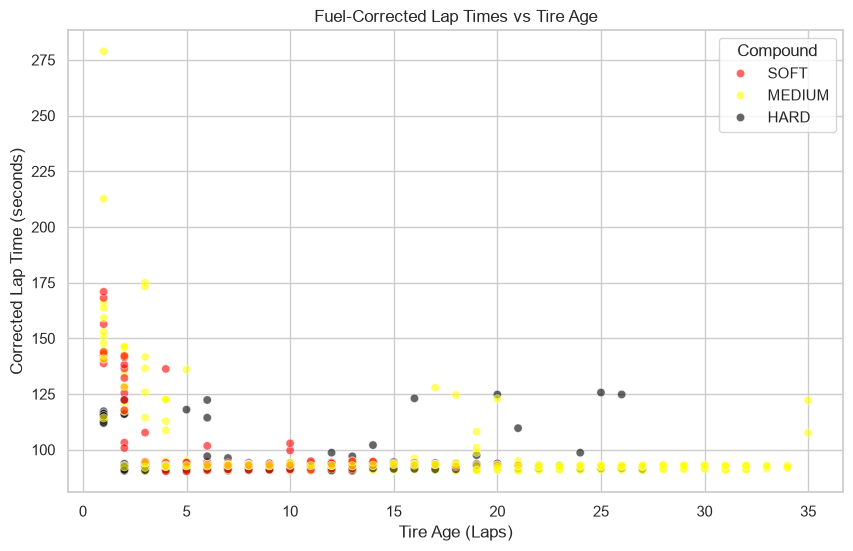

In [4]:
total_laps = 52
laps["laps_remaining"] = total_laps - laps["LapNumber"]
laps["fuel_kg"] = laps["laps_remaining"] * 1.9
laps["fuel_effect"] = laps["fuel_kg"] * 0.033
laps["LapTime_corrected"] = laps["LapTime_s"] - laps["fuel_effect"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=laps, x="TyreLife", y="LapTime_corrected", hue="Compound", palette=tyre_palette, alpha=0.6)
plt.title("Fuel-Corrected Lap Times vs Tire Age")
plt.xlabel("Tire Age (Laps)")
plt.ylabel("Corrected Lap Time (seconds)")
plt.show()

## 4. Normalize per Driver-Stint and Fit Piecewise Degradation Curves

### Description & Representation
This plot shows the normalized median tire degradation penalty (in seconds) vs tire age (`TyreLife`) as yellow scatter points, overlaid with the fitted piecewise regression curve (in orange) and a red vertical dashed line representing the calculated `cliff_age`.

### Technical Details
1. **Normalization**: To remove driver/car pace offsets, we group laps by `Driver` and `Stint` and subtract each stint's baseline pace (5th percentile of fuel-corrected times):
   $$\text{deg}_{d,s}(t) = T_{\text{corrected}}(t) - \text{Baseline}_{d,s}$$
2. **Piecewise Fitting**: We fit the following piecewise degradation function using non-linear least squares (`scipy.optimize.curve_fit`):
   $$\text{deg}(t) = \text{base\_deg} \cdot t + \text{cliff\_severity} \cdot \max(0, t - \text{cliff\_age})^2$$
   Strict boundaries are enforced to prevent non-physical results (e.g. negative degradation or cliff age outside stint lengths).

### Strategic Insights
This normalization isolates the pure tire degradation profile. We clearly see a **linear, gradual pace loss phase** (representing normal wear) followed by a **sudden quadratic pace loss** past the threshold (cliff age at $\approx 33.1$ laps), where performance drops off exponentially. This threshold is the single most important parameter for a strategist, as it dictates the optimal pit stop window.

Fitted Params - Base Deg: 0.0271 s/lap, Cliff Age: 33.0 laps, Cliff Severity: 0.3072


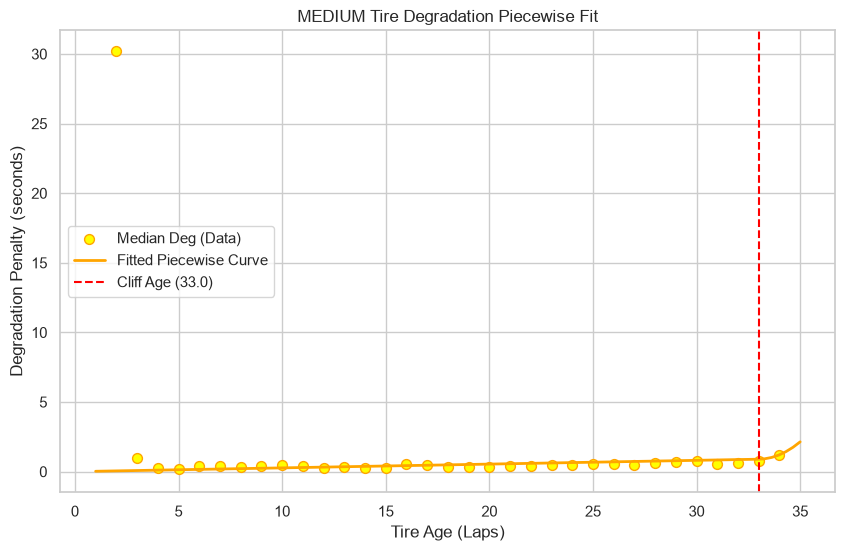

In [5]:
# Normalize stint to remove driver/car pace offset
clean_laps = laps[(laps["TrackStatus"] == "1") & (laps["IsAccurate"] == True)].copy()
normalized_list = []
for (driver, stint), group in clean_laps.groupby(["Driver", "Stint"]):
    if len(group) < 3:
        continue
    baseline = group["LapTime_corrected"].quantile(0.05)
    group["deg"] = group["LapTime_corrected"] - baseline
    normalized_list.append(group)
df_norm = pd.concat(normalized_list, ignore_index=True)

def piecewise_deg(age, base_deg, cliff_age, cliff_sev):
    gradual = base_deg * age
    cliff = cliff_sev * np.maximum(0, age - cliff_age) ** 2
    return gradual + cliff

# Fit for MEDIUM compound
med_laps = df_norm[df_norm["Compound"] == "MEDIUM"]
age_median = med_laps.groupby("TyreLife")["deg"].median().reset_index()

popt, _ = curve_fit(piecewise_deg, age_median["TyreLife"].values, age_median["deg"].values, p0=[0.05, 20.0, 0.2], bounds=([0, 5, 0], [0.5, 45, 2.0]))
base_deg, cliff_age, cliff_sev = popt
print(f"Fitted Params - Base Deg: {base_deg:.4f} s/lap, Cliff Age: {cliff_age:.1f} laps, Cliff Severity: {cliff_sev:.4f}")

# Plot Fit using yellow/gold colors for Medium compound theme
plt.figure(figsize=(10, 6))
plt.scatter(age_median["TyreLife"], age_median["deg"], label="Median Deg (Data)", color="yellow", edgecolors="orange", s=50)
x_fit = np.linspace(1, 35, 100)
y_fit = piecewise_deg(x_fit, base_deg, cliff_age, cliff_sev)
plt.plot(x_fit, y_fit, label="Fitted Piecewise Curve", color="orange", lw=2)
plt.axvline(cliff_age, color="red", linestyle="--", label=f"Cliff Age ({cliff_age:.1f})")
plt.title("MEDIUM Tire Degradation Piecewise Fit")
plt.xlabel("Tire Age (Laps)")
plt.ylabel("Degradation Penalty (seconds)")
plt.legend()
plt.show()

## 5. Safety Car Laps Frequency

### Description & Representation
This bar chart shows the active safety car rate (y-axis) plotted against the lap number (x-axis) across seasons.

### Technical Details
Laps are classified using `TrackStatus` flags containing `'4'` (Safety Car) or `'6'` (Virtual Safety Car). Grouping by `LapNumber` allows us to calculate the empirical probability of a safety car deployment on each specific lap.

### Strategic Insights
The bar chart highlights safety car "hot spots". The probability spikes on Lap 1 and 2 due to start-line collisions and turn 1 incidents. It also shows secondary spikes on laps where tires are heavily worn and drivers are prone to spin. This empirical distribution helps seed the safety car transition probability in the Gymnasium MDP.

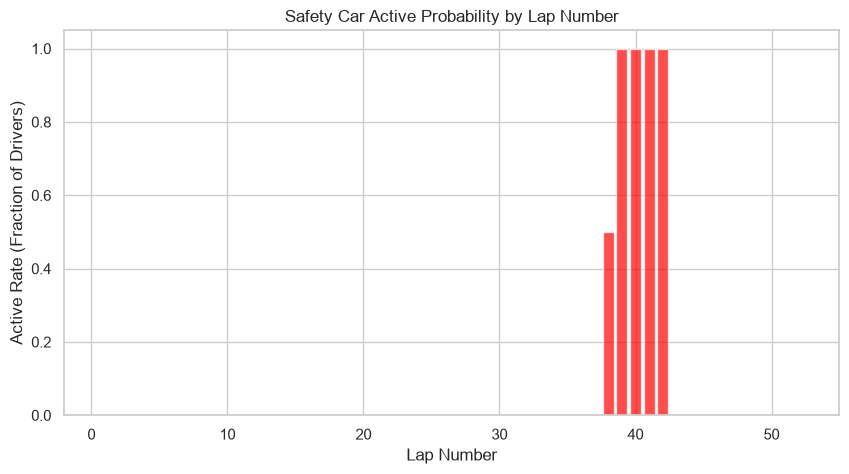

In [6]:
laps["sc_active"] = laps["TrackStatus"].astype(str).str.contains("4")
sc_by_lap = laps.groupby("LapNumber")["sc_active"].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.bar(sc_by_lap["LapNumber"], sc_by_lap["sc_active"], color="red", alpha=0.7)
plt.title("Safety Car Active Probability by Lap Number")
plt.xlabel("Lap Number")
plt.ylabel("Active Rate (Fraction of Drivers)")
plt.show()